# Cosmic Intelligence Lab

## Deep Galaxy Explorer — Study 001

# Notebook 004 — Visualizing Deep Field Images

### Research Question

How do different astronomical image visualization techniques influence our ability to detect and interpret faint galaxies in deep-field Hubble observations?

### Objectives

- Load the calibrated Hubble F160W science image.
- Compare multiple image stretching techniques.
- Evaluate visualization methods used in astronomical research.
- Produce publication-quality images.
- Identify the visualization best suited for automated source detection.
- Prepare the image for scientific measurement in Notebook 005.

### Expected Outcomes

By the end of this notebook we will:

- Understand the strengths and weaknesses of different image stretches.
- Produce high-quality visualizations of the Hubble Ultra Deep Field.
- Establish a standard visualization pipeline for Cosmic Intelligence Lab.
- Select the optimal image representation for galaxy detection and AI analysis.

In [1]:
# Cell 2 - Import Required Libraries ===========================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.visualization import (
    ImageNormalize,
    PercentileInterval,
    AsinhStretch,
    LogStretch,
    LinearStretch,
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Cell 3 - Load the Hubble Science Image =======================

fits_file = Path(
    "../data/raw/mastDownload/HST/ib5x1fetq/ib5x1fetq_flt.fits"
)

with fits.open(fits_file) as hdul:
    science = hdul["SCI"].data.copy()

print("Image loaded successfully.")
print(f"Shape : {science.shape}")
print(f"Type  : {science.dtype}")

Image loaded successfully.
Shape : (1014, 1014)
Type  : >f4


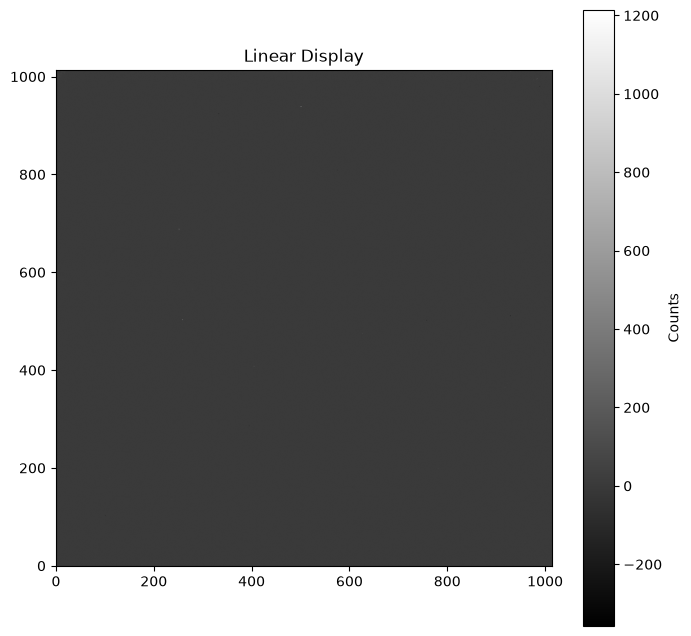

In [3]:
# Cell 4 - Linear Display ======================================

plt.figure(figsize=(8,8))

plt.imshow(
    science,
    origin="lower",
    cmap="gray"
)

plt.title("Linear Display")

plt.colorbar(label="Counts")

plt.show()

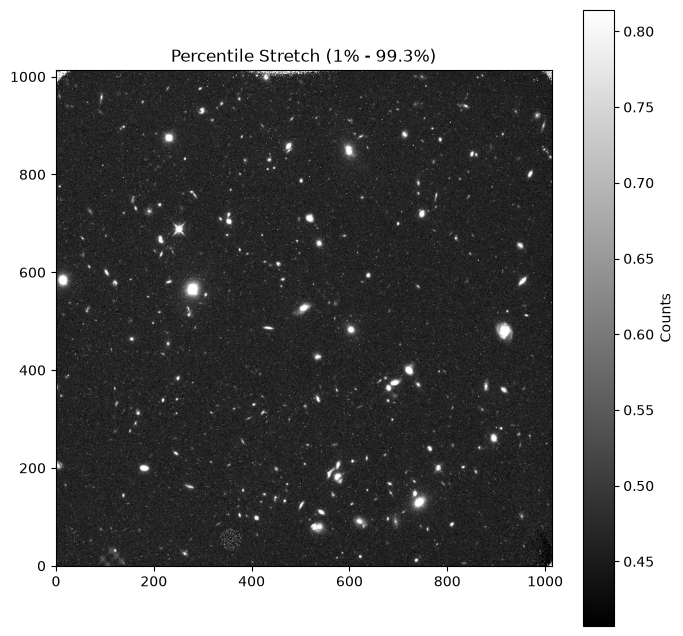

In [5]:
# Cell 5 - Percentile Stretch ==================================

vmin = np.percentile(science, 1)
vmax = np.percentile(science, 99.3)

plt.figure(figsize=(8,8))
### Scientific Evaluation – Percentile Stretch (1%–99.3%)

# The percentile stretch produces an excellent visualization of the Hubble WFC3/Multi-Wavelength View 
# of the GalaxyMulti-Wavelength View of the GalaxyIR F160W image. Numerous faint galaxies become visible 
# while preserving the structure of brighter galaxies and foreground stars. Background noise remains 
# acceptable and detector artifacts are easily recognized.

# This visualization provides an effective balance between contrast and dynamic range and serves as the 
# current reference display for subsequent comparisons.

plt.imshow(
    science,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.title("Percentile Stretch (1% - 99.3%)")

plt.colorbar(label="Counts")

plt.show()

### Scientific Evaluation – Percentile Stretch (1%–99.3%)

The percentile stretch produces an excellent visualization of the Hubble WFC3/IR F160W image. Numerous faint galaxies become visible while preserving the structure of brighter galaxies and foreground stars. Background noise remains acceptable and detector artifacts are easily recognized.

This visualization provides an effective balance between contrast and dynamic range and serves as the current reference display for subsequent comparisons.

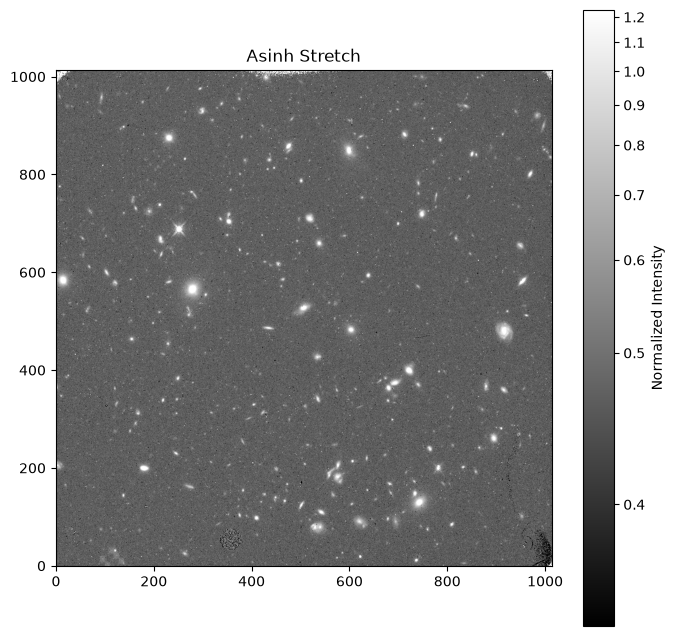

In [6]:
# Cell 6 - Asinh Stretch =======================================

from astropy.visualization import ImageNormalize, AsinhStretch

norm = ImageNormalize(
    science,
    interval=PercentileInterval(99.3),
    stretch=AsinhStretch()
)

plt.figure(figsize=(8,8))

plt.imshow(
    science,
    origin="lower",
    cmap="gray",
    norm=norm
)

plt.title("Asinh Stretch")

plt.colorbar(label="Normalized Intensity")

plt.show()

### Scientific Evaluation – Asinh Stretch

The Asinh stretch compresses the dynamic range of the image while preserving faint astronomical sources. Compared with the percentile stretch, the background sky appears brighter and low-level structure becomes slightly more apparent. However, the increased background also reduces overall image contrast.

The Asinh stretch is well suited for interactive visual inspection of faint objects, while the percentile stretch provides a cleaner overall presentation.

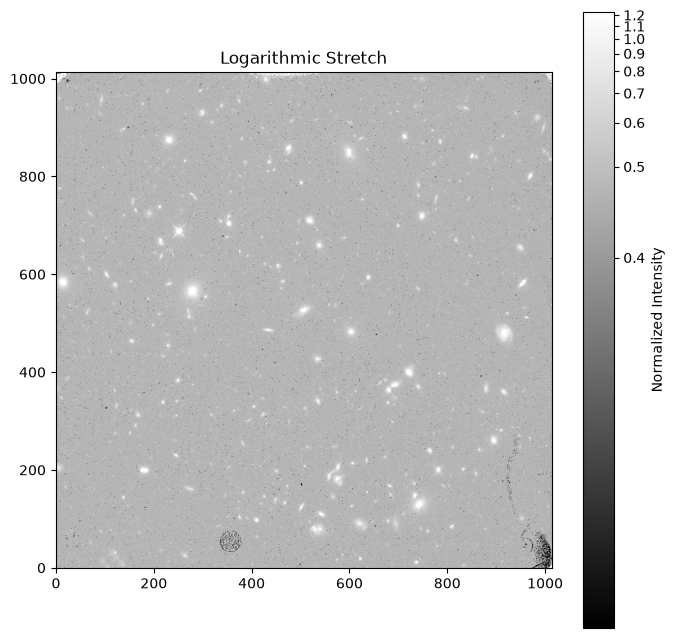

In [7]:
# Cell 7 - Logarithmic Stretch ================================

from astropy.visualization import LogStretch

norm = ImageNormalize(
    science,
    interval=PercentileInterval(99.3),
    stretch=LogStretch()
)

plt.figure(figsize=(8, 8))

plt.imshow(
    science,
    origin="lower",
    cmap="gray",
    norm=norm
)

plt.title("Logarithmic Stretch")

plt.colorbar(label="Normalized Intensity")

plt.show()

### Scientific Evaluation – Logarithmic Stretch

The logarithmic stretch strongly enhances faint astronomical sources while compressing the brightest regions of the image. This technique is particularly useful for revealing low-surface-brightness galaxies and extended structures that are difficult to see with a linear display.

Although excellent for visual exploration, the increased emphasis on faint features may also enhance background noise and reduce contrast around bright objects.

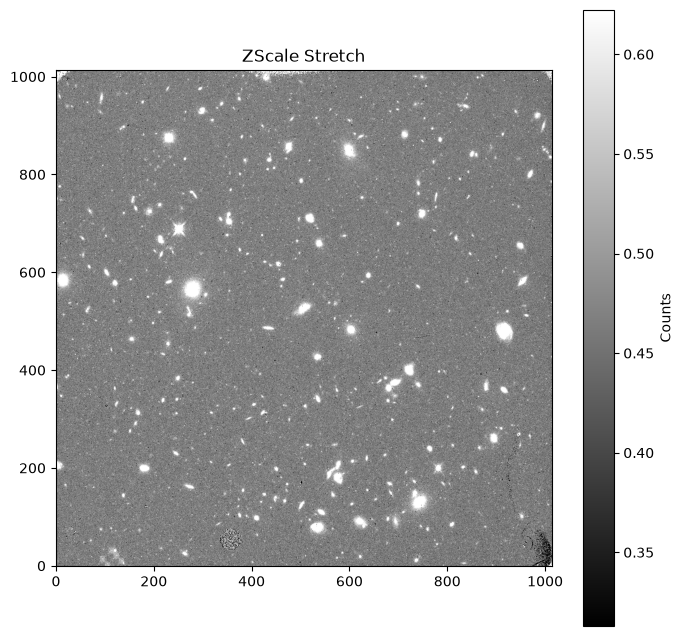

In [8]:
# Cell 8 - ZScale Stretch =====================================

from astropy.visualization import ZScaleInterval

interval = ZScaleInterval()

vmin, vmax = interval.get_limits(science)

plt.figure(figsize=(8,8))

plt.imshow(
    science,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.title("ZScale Stretch")

plt.colorbar(label="Counts")

plt.show()

### Scientific Evaluation – ZScale Stretch

The ZScale algorithm automatically determines an appropriate display range by analyzing the distribution of pixel values. This approach has become the standard visualization technique in professional astronomical software because it produces a balanced representation without requiring manual adjustment.

ZScale provides an excellent first-look visualization and serves as a valuable reference against manually selected percentile stretches.

In [9]:
# Cell 9 - Visualization Summary ==============================

methods = {
    "Linear": 2,
    "Percentile (1–99.3%)": 5,
    "Asinh": 4,
    "Logarithmic": 3,
    "ZScale": 4,
}

print("=" * 60)
print("Visualization Comparison")
print("=" * 60)

for method, rating in methods.items():
    print(f"{method:<24} {'★' * rating}")

print("\nRecommended visualization:")
print("Percentile Stretch (1% - 99.3%)")

Visualization Comparison
Linear                   ★★
Percentile (1–99.3%)     ★★★★★
Asinh                    ★★★★
Logarithmic              ★★★
ZScale                   ★★★★

Recommended visualization:
Percentile Stretch (1% - 99.3%)


### Final Assessment

Five visualization techniques were evaluated using the calibrated Hubble WFC3/IR F160W image.

The percentile stretch (1%–99.3%) provided the best balance between contrast, visibility of faint galaxies, suppression of background noise, and preservation of bright objects. This method was selected as the standard visualization for the remainder of Deep Galaxy Explorer – Study 001.

Future notebooks will use this visualization when displaying images and evaluating the performance of automated source detection algorithms.

In [10]:
# Cell 10 - Notebook Status ===================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 04_visualizing_deep_field_images.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))

print("\nVisualization methods evaluated:")
print("✓ Linear")
print("✓ Percentile")
print("✓ Asinh")
print("✓ Logarithmic")
print("✓ ZScale")

print("\nRecommended display: Percentile Stretch (1%–99.3%)")
print("Ready for Notebook 005.")

Notebook Status
Status    : PASS
Notebook  : 04_visualizing_deep_field_images.ipynb
Completed : 2026-07-27 15:17

Visualization methods evaluated:
✓ Linear
✓ Percentile
✓ Asinh
✓ Logarithmic
✓ ZScale

Recommended display: Percentile Stretch (1%–99.3%)
Ready for Notebook 005.
